#

#Import Modules

In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

#If we run on Google Colab, otherwise change
from google.colab import drive
drive.mount('/content/drive')
os.chdir('/content/drive/MyDrive/Pavement/Pavement_Equity_Dadzoe/Pavement_Inventory')
###

Mounted at /content/drive


#Read and Explore Data

##Reading Data

<Axes: >

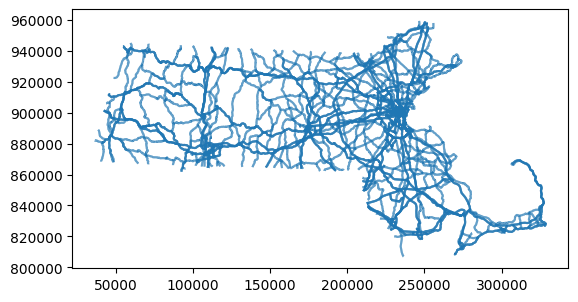

In [2]:
pavement_shp=gpd.read_file('Data/MergedV2_Pavement_Inventory_Fina_2024.shp')
pavement_shp['Lane_Mi']=pavement_shp['Num_Lanes']*pavement_shp['Length']
pavement_shp.plot()

<Axes: >

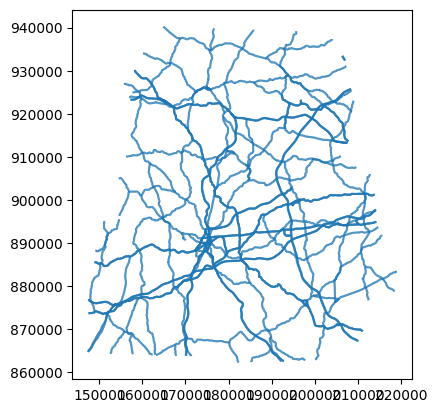

In [3]:
Dist3=pavement_shp[pavement_shp['Hwy_Dist']==3].copy()
Dist3.plot()

##Data Pre-processing
Analyze the data such that the inputs are normalized and the prioritization strategy metrics are defined

In [4]:
#Priority Assignment
maxAADT,minAADT=Dist3['AADT'].max(),Dist3['AADT'].min()
maxIRI,minIRI=Dist3['IRI'].max(),Dist3['IRI'].min()
maxPOP,minPOP=Dist3['sumpop'].max(),Dist3['sumpop'].min()
#maxPOP=1000
POP90=Dist3['sumpop'].quantile(q=0.9)
AADT90=Dist3['AADT'].quantile(q=0.9)

Dist3['C']=Dist3['IRI']
Dist3['T']=1+(Dist3['AADT']-minAADT)/(AADT90-minAADT)
Dist3['P']=1+(Dist3['sumpop']-minPOP)/(POP90-minPOP)
Dist3.loc[Dist3['T']>2,'T']=2
Dist3.loc[Dist3['P']>2,'P']=2

Dist3['C_T_P']=(Dist3['C']*Dist3['T']*Dist3['P'])
Dist3['C_T']=(Dist3['C']*Dist3['T'])
Dist3['C_P']=(Dist3['C']*Dist3['P'])

Distribution of IRI Categories (by Lane-Miles):


/tmp/ipykernel_26898/3177117463.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  iri_counts_lane_mi = Dist3.groupby('IRI_Category')['Lane_Mi'].sum().reindex(labels)


,Total Lane Miles,Percentage (%)
IRI_Category,,
Very Good,870.258708,28.939828
Good,552.230134,18.364016
Fair,963.520859,32.041193
Poor,337.439589,11.221311
Very Poor,283.682332,9.433652


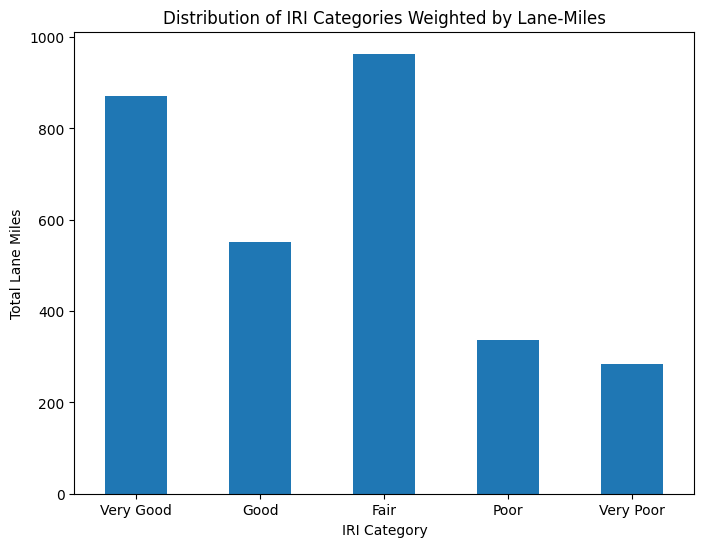

In [5]:
bins = [0, 60, 95, 170, 220, Dist3['IRI'].max()]
labels = ['Very Good','Good', 'Fair', 'Poor', 'Very Poor']
Dist3['IRI_Category'] = pd.cut(Dist3['IRI'], bins=bins, labels=labels, right=False)

iri_counts_lane_mi = Dist3.groupby('IRI_Category')['Lane_Mi'].sum().reindex(labels)

# Calculate percentages
total_lane_mi = iri_counts_lane_mi.sum()
iri_percentages_lane_mi = (iri_counts_lane_mi / total_lane_mi) * 100

print("Distribution of IRI Categories (by Lane-Miles):")
display(pd.DataFrame({'Total Lane Miles': iri_counts_lane_mi, 'Percentage (%)': iri_percentages_lane_mi}))

plt.figure(figsize=(8, 6))
iri_counts_lane_mi.plot(kind='bar')
plt.title('Distribution of IRI Categories Weighted by Lane-Miles')
plt.xlabel('IRI Category')
plt.ylabel('Total Lane Miles')
plt.xticks(rotation=0)
plt.show()

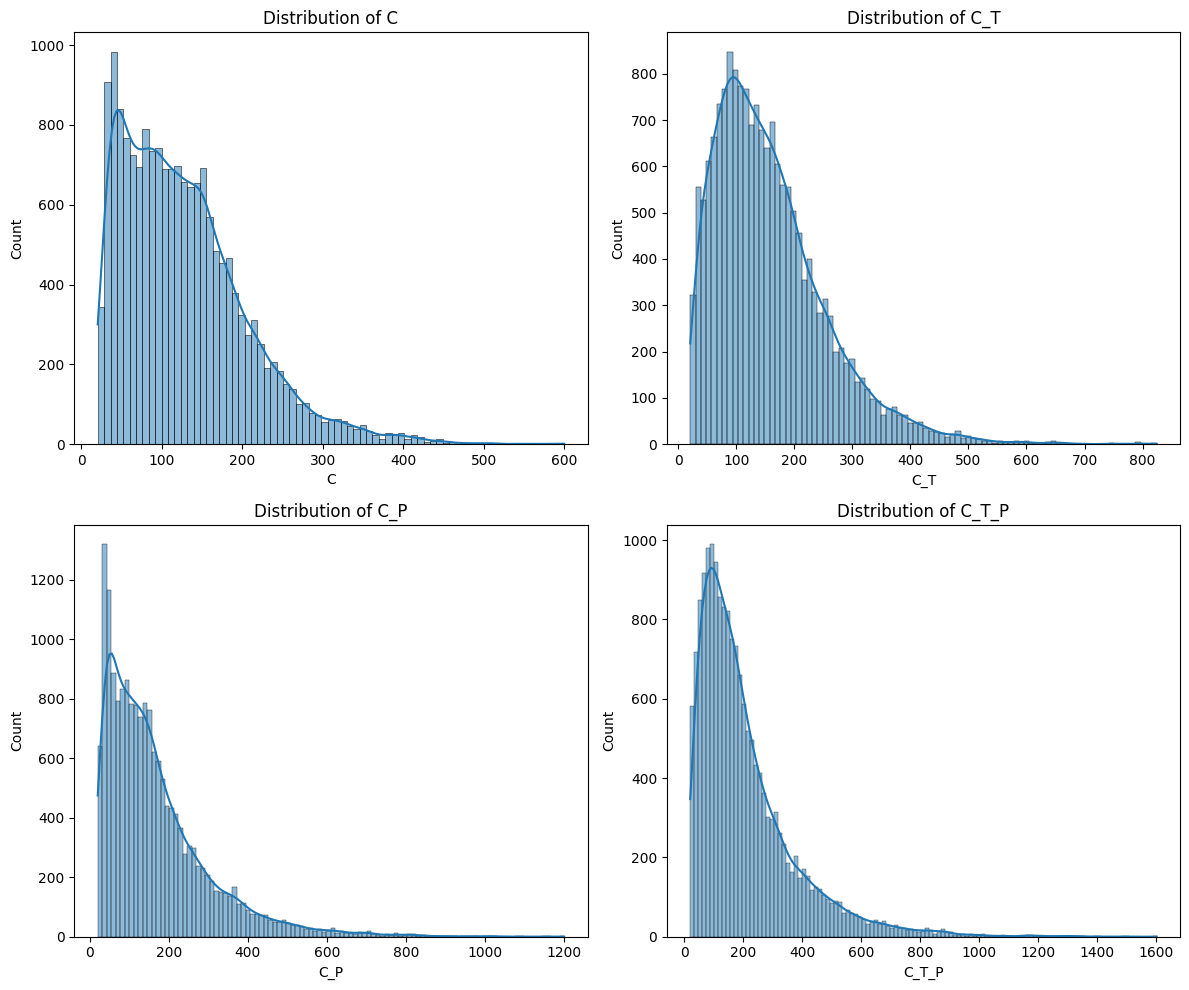

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
sns.histplot(Dist3['C'], ax=axes[0, 0], kde=True)
axes[0, 0].set_title('Distribution of C')
#axes[0, 0].set_xlim(0, 2)
sns.histplot(Dist3['C_T'], ax=axes[0, 1], kde=True)
axes[0, 1].set_title('Distribution of C_T')
##axes[0, 1].set_xlim(0, 2)
sns.histplot(Dist3['C_P'], ax=axes[1, 0], kde=True)
axes[1, 0].set_title('Distribution of C_P')
#axes[1, 0].set_xlim(0, 2)
sns.histplot(Dist3['C_T_P'], ax=axes[1, 1], kde=True)
axes[1, 1].set_title('Distribution of C_T_P')
#axes[1, 1].set_xlim(0, 2)
plt.tight_layout()
plt.show()

##Finding Lengths
For sanity check, find and report the lengths of roadways

In [7]:
Dist3['Lane_Mi'].sum()

np.float64(3007.5316225447314)

In [8]:
Dist3[Dist3['IRI']>220]['Lane_Mi'].sum()

np.float64(283.88233224117295)

In [9]:
Dist3[(Dist3['Condition']=='Poor')|(Dist3['Condition']=='Fair')]['Length'].sum()

np.float64(597.2210083442953)

In [10]:
fix_length=300
IRI_reset=40

##Prioritization Strategies

Take the road dataset and returns the road segments to be fixed within a lane-mile budget given strategy

In [11]:
# Define your parameters here
fix_length = 150
IRI_reset = 40

# Create  copies and sort them in one step
Dist3_C = Dist3.sort_values(by='C', ascending=False).copy()
Dist3_CT = Dist3.sort_values(by='C_T', ascending=False).copy()
Dist3_CP = Dist3.sort_values(by='C_P', ascending=False).copy()
Dist3_CTP = Dist3.sort_values(by='C_T_P', ascending=False).copy()

# A dictionary to hold the  dataframes
dfs = {'C': Dist3_C, 'C_T': Dist3_CT, 'C_P': Dist3_CP, 'C_T_P': Dist3_CTP}
fixed_roads = {} # To store the results

# Iterate and modify the  copies
for name, df in dfs.items():
    cumulative_lane_mi = 0
    ids_to_fix = []
    for index, row in df.iterrows():
        if cumulative_lane_mi < fix_length:
            # Add the ID to our list for this strategy
            ids_to_fix.append(row['OBJECTID'])
            cumulative_lane_mi += row['Lane_Mi']
        else:
            break

    # Store the list of fixed road IDs
    fixed_roads[name] = ids_to_fix

    # Apply the IRI change to the dataframe
    df.loc[df['OBJECTID'].isin(ids_to_fix), 'IRI'] = IRI_reset

# Now can use the 'dfs' and 'fixed_roads' dictionaries for your plotting and analysis
print("Roads fixed using the 'C' strategy:", fixed_roads['C'])

display(dfs['C'].head())

Roads fixed using the 'C' strategy: [16359, 78372, 16206, 45818, 16353, 16214, 23850, 95198, 16333, 16332, 94273, 16216, 16209, 79721, 16355, 16198, 16197, 16205, 48322, 15874, 15916, 16354, 23964, 95460, 94599, 33956, 67132, 16357, 86320, 46130, 87681, 67158, 67126, 45169, 16352, 79720, 94295, 34117, 35290, 34799, 34094, 78370, 36009, 48334, 35019, 48323, 35296, 33021, 45809, 67351, 26173, 78375, 33035, 44852, 16212, 16334, 70356, 33751, 16213, 35266, 35480, 28677, 16331, 94275, 92594, 75964, 95200, 66215, 67160, 67349, 16358, 16215, 35289, 67140, 28859, 70354, 67156, 67683, 16189, 35021, 95219, 94665, 94860, 95193, 61269, 94292, 92600, 70384, 69801, 69790, 36578, 95201, 44858, 38391, 38095, 95588, 15954, 15936, 70140, 48320, 36050, 78371, 86307, 66396, 67352, 94663, 95217, 87664, 86900, 88690, 23066, 69486, 87683, 95216, 48299, 48178, 61403, 70364, 29605, 34242, 35037, 49549, 35256, 33957, 69700, 69773, 69799, 70377, 95197, 46133, 35047, 48301, 95194, 94293, 86308, 34962, 16210, 1620

,Join_Count,TARGET_FID,Join_Cou_1,TARGET_F_1,OBJECTID,Route_ID,From_Date,To_Date,From_Measu,To_Measure,...,Shape_Le_3,geometry,Lane_Mi,C,T,P,C_T_P,C_T,C_P,IRI_Category
62251,1,62251,28,62251,16359,N056 SB,2025-05-27,NaT,1.5,1.517,...,27.358969,"LINESTRING Z (196606.697 900067.534 0, 196633....",0.0,600.00,1.373881,1.682432,1386.877150,824.328587,1009.459459,NaN
44111,3,44111,17,44111,78372,SR62 EB,2025-05-27,NaT,24.6,24.700,...,160.934380,"LINESTRING Z (184368.471 907897.299 0, 184428 ...",0.2,600.00,1.231605,1.493243,1103.451885,738.963253,895.945946,NaN
10993,2,10993,22,10993,16206,N051 EB,2025-05-27,NaT,0.5,0.600,...,157.759780,"LINESTRING Z (175610.868 925731.747 0, 175656....",0.2,600.00,1.109792,2.000000,1331.750362,665.875181,1200.000000,NaN
25684,1,25684,3,25684,45818,SR140 SB,2025-05-27,NaT,14.7,14.800,...,160.934712,"LINESTRING Z (168838.074 918228.691 0, 168839....",0.0,596.21,1.099156,1.033784,677.467213,655.327762,616.352230,Very Poor
11062,7,11062,70,11062,16353,N056 SB,2025-05-27,NaT,0.9,1.000,...,160.934692,"LINESTRING Z (195677.484 899825.312 0, 195714....",0.0,582.69,1.373881,2.000000,1601.093415,800.546708,1165.380000,Very Poor


In [12]:
#First create empty lists
fixed_roads_C = []
fixed_roads_CT = []
fixed_roads_CP = []
fixed_roads_CTP = []

In [13]:
#Iterate through each dataframe and append the 'Route_ID' to the corresponding list if the 'IRI' is equal to the reset value.
for index, row in dfs['C'].iterrows():
    if row['IRI'] == IRI_reset:
        fixed_roads_C.append(row['OBJECTID'])
    else:
        break

for index, row in dfs['C_T'].iterrows():
    if row['IRI'] == IRI_reset:
        fixed_roads_CT.append(row['OBJECTID'])
    else:
        break

for index, row in dfs['C_P'].iterrows():
    if row['IRI'] == IRI_reset:
        fixed_roads_CP.append(row['OBJECTID'])
    else:
        break

for index, row in dfs['C_T_P'].iterrows():
    if row['IRI'] == IRI_reset:
        fixed_roads_CTP.append(row['OBJECTID'])
    else:
        break

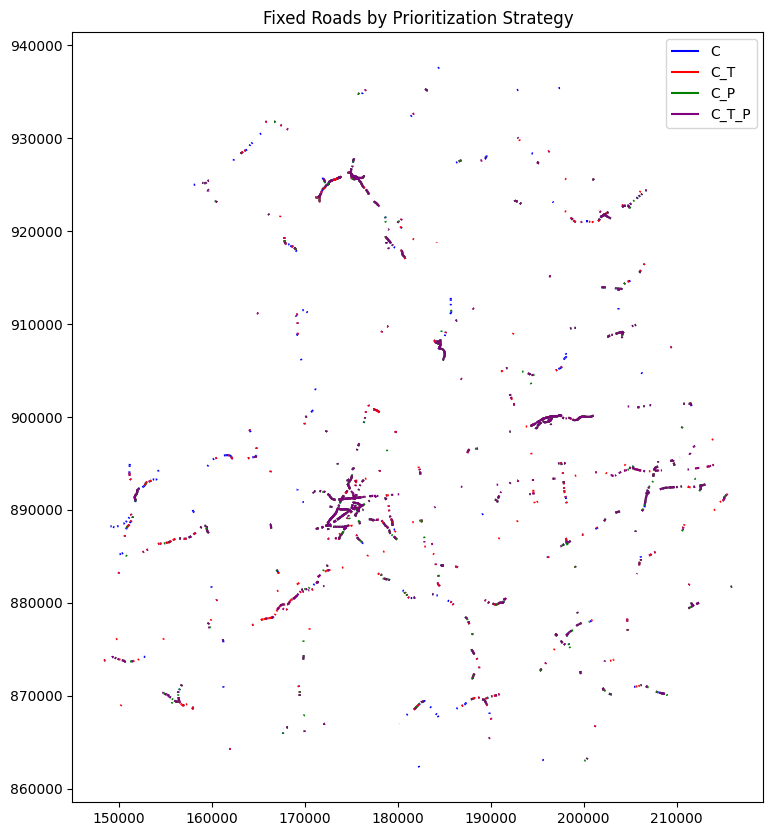

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
Dist3[Dist3['OBJECTID'].isin(fixed_roads_C)].plot(ax=ax, color='blue', label='C')
Dist3[Dist3['OBJECTID'].isin(fixed_roads_CT)].plot(ax=ax, color='red', label='C_T')
Dist3[Dist3['OBJECTID'].isin(fixed_roads_CP)].plot(ax=ax, color='green', label='C_P')
Dist3[Dist3['OBJECTID'].isin(fixed_roads_CTP)].plot(ax=ax, color='purple', label='C_T_P')
ax.set_title('Fixed Roads by Prioritization Strategy')
ax.legend()
plt.show()

In [14]:
print(np.sum(Dist3['IRI']*Dist3['Lane_Mi'])/np.sum(Dist3['Lane_Mi']))
print(np.sum(dfs['C_T']['IRI']*dfs['C_T']['Lane_Mi'])/np.sum(dfs['C_T']['Lane_Mi']))
print(np.sum(dfs['C_P']['IRI']*dfs['C_P']['Lane_Mi'])/np.sum(dfs['C_P']['Lane_Mi']))
print(np.sum(dfs['C_T_P']['IRI']*dfs['C_T_P']['Lane_Mi'])/np.sum(dfs['C_T_P']['Lane_Mi']))
print(np.sum(dfs['C']['IRI']*dfs['C']['Lane_Mi'])/np.sum(dfs['C']['Lane_Mi']))

115.83632286594322
102.64181507182693
103.35607039165548
103.72968103086039
101.97876901258192


/tmp/ipykernel_26898/4115602343.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  iri_counts_before = Dist3.groupby('IRI_Category_Before')['Lane_Mi'].sum().reindex(labels)
/tmp/ipykernel_26898/4115602343.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  iri_counts_C_after = dfs['C'].groupby('IRI_Category_After')['Lane_Mi'].sum().reindex(labels)
/tmp/ipykernel_26898/4115602343.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence thi

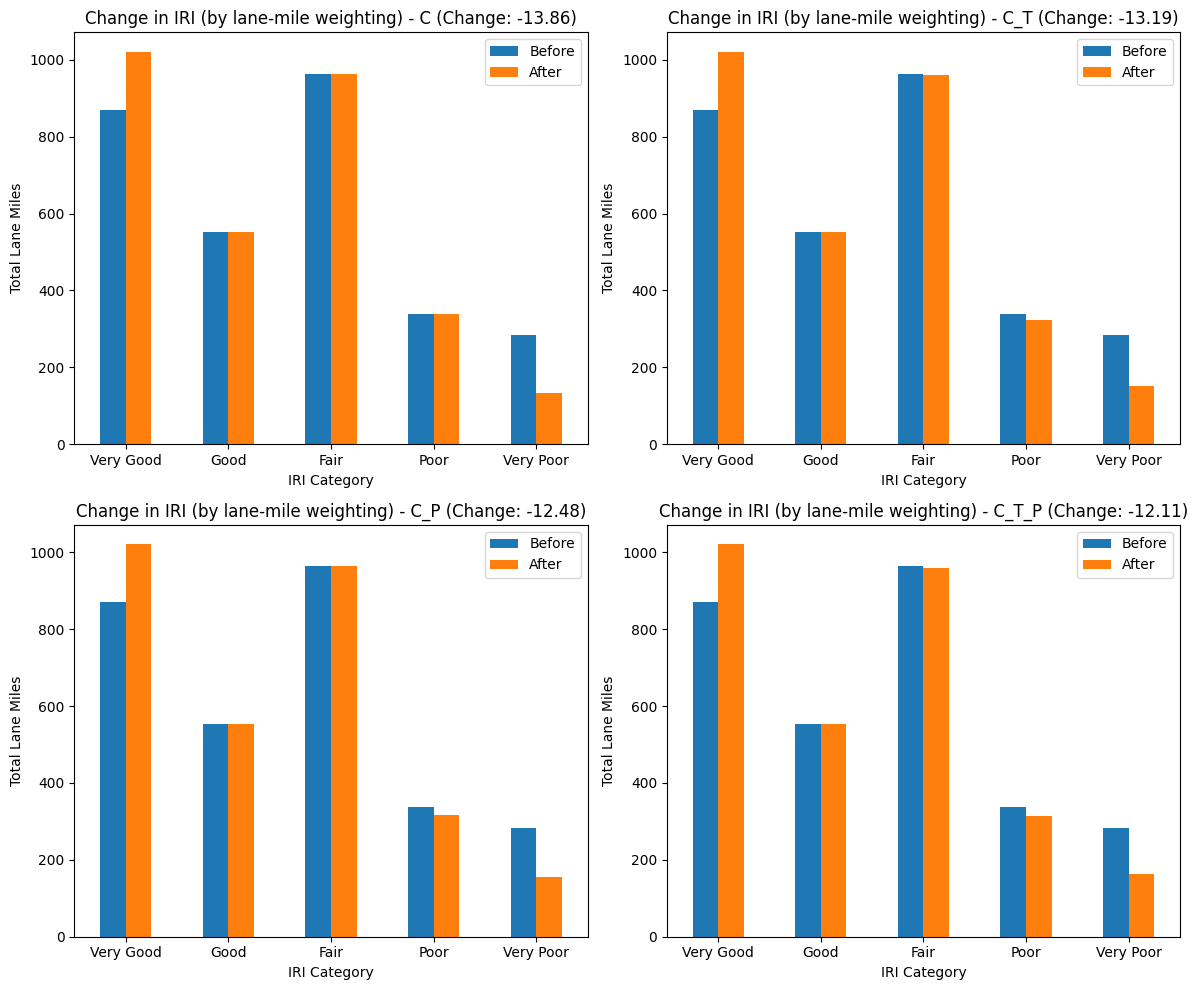

In [15]:
bins = [0, 60, 95, 170, 220, Dist3['IRI'].max()]
labels = ['Very Good','Good', 'Fair', 'Poor', 'Very Poor']

# Calculate IRI distribution before applying any strategy
Dist3['IRI_Category_Before'] = pd.cut(Dist3['IRI'], bins=bins, labels=labels, right=False)
iri_counts_before = Dist3.groupby('IRI_Category_Before')['Lane_Mi'].sum().reindex(labels)

# Calculate average weighted IRI before
avg_iri_before = (Dist3['IRI'] * Dist3['Lane_Mi']).sum() / Dist3['Lane_Mi'].sum()


fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Plot for Dist3_C
dfs['C']['IRI_Category_After'] = pd.cut(dfs['C']['IRI'], bins=bins, labels=labels, right=False)
iri_counts_C_after = dfs['C'].groupby('IRI_Category_After')['Lane_Mi'].sum().reindex(labels)
avg_iri_C_after = (dfs['C']['IRI'] * dfs['C']['Lane_Mi']).sum() / dfs['C']['Lane_Mi'].sum()
change_C = avg_iri_C_after - avg_iri_before
pd.DataFrame({'Before': iri_counts_before, 'After': iri_counts_C_after}).plot(kind='bar', ax=axes[0, 0])
axes[0, 0].set_title(f'Change in IRI (by lane-mile weighting) - C (Change: {change_C:.2f})')
axes[0, 0].set_xlabel('IRI Category')
axes[0, 0].set_ylabel('Total Lane Miles')
axes[0, 0].tick_params(axis='x', rotation=0)

# Plot for Dist3_CT
dfs['C_T']['IRI_Category_After'] = pd.cut(dfs['C_T']['IRI'], bins=bins, labels=labels, right=False)
iri_counts_CT_after = dfs['C_T'].groupby('IRI_Category_After')['Lane_Mi'].sum().reindex(labels)
avg_iri_CT_after = (dfs['C_T']['IRI'] * dfs['C_T']['Lane_Mi']).sum() / dfs['C_T']['Lane_Mi'].sum()
change_CT = avg_iri_CT_after - avg_iri_before
pd.DataFrame({'Before': iri_counts_before, 'After': iri_counts_CT_after}).plot(kind='bar', ax=axes[0, 1])
axes[0, 1].set_title(f'Change in IRI (by lane-mile weighting) - C_T (Change: {change_CT:.2f})')
axes[0, 1].set_xlabel('IRI Category')
axes[0, 1].set_ylabel('Total Lane Miles')
axes[0, 1].tick_params(axis='x', rotation=0)

# Plot for Dist3_CP
dfs['C_P']['IRI_Category_After'] = pd.cut(dfs['C_P']['IRI'], bins=bins, labels=labels, right=False)
iri_counts_CP_after = dfs['C_P'].groupby('IRI_Category_After')['Lane_Mi'].sum().reindex(labels)
avg_iri_CP_after = (dfs['C_P']['IRI'] * dfs['C_P']['Lane_Mi']).sum() / dfs['C_P']['Lane_Mi'].sum()
change_CP = avg_iri_CP_after - avg_iri_before
pd.DataFrame({'Before': iri_counts_before, 'After': iri_counts_CP_after}).plot(kind='bar', ax=axes[1, 0])
axes[1, 0].set_title(f'Change in IRI (by lane-mile weighting) - C_P (Change: {change_CP:.2f})')
axes[1, 0].set_xlabel('IRI Category')
axes[1, 0].set_ylabel('Total Lane Miles')
axes[1, 0].tick_params(axis='x', rotation=0)

# Plot for Dist3_CTP
dfs['C_T_P']['IRI_Category_After'] = pd.cut(dfs['C_T_P']['IRI'], bins=bins, labels=labels, right=False)
iri_counts_CTP_after = dfs['C_T_P'].groupby('IRI_Category_After')['Lane_Mi'].sum().reindex(labels)
avg_iri_CTP_after = (dfs['C_T_P']['IRI'] * dfs['C_T_P']['Lane_Mi']).sum() / dfs['C_T_P']['Lane_Mi'].sum()
change_CTP = avg_iri_CTP_after - avg_iri_before
pd.DataFrame({'Before': iri_counts_before, 'After': iri_counts_CTP_after}).plot(kind='bar', ax=axes[1, 1])
axes[1, 1].set_title(f'Change in IRI (by lane-mile weighting) - C_T_P (Change: {change_CTP:.2f})')
axes[1, 1].set_xlabel('IRI Category')
axes[1, 1].set_ylabel('Total Lane Miles')
axes[1, 1].tick_params(axis='x', rotation=0)


plt.tight_layout()
plt.show()

##Block Group Integration
To do equity analysis, we will read the block groups and merge them with our road dataset.

<Axes: >

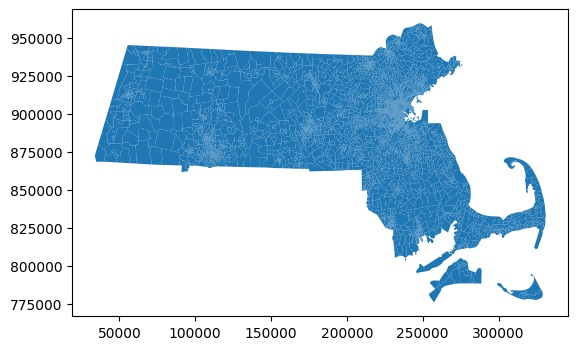

In [16]:
Block_Groups=gpd.read_file('Data/BlockGroups_all.shp')
Block_Groups.plot()

In [17]:
Block_Groups

,Geographic,GEOID,split_for_,Municipali,Totsl_pop,NonHispWhi,pct_minori,TotalHH,limEngHH,limEngHHpc,...,medianHHI,limitedEng,minority_p,EJ,EJ_CRITERI,EJ_crite_1,EJ_CRIT_DE,Shape_Leng,Shape_Area,geometry
0,"Block Group 1, Census Tract 101, Barnstable Co...",250010101001,N,Provincetown,992.0,865.0,12.802419,519.0,0,0.000000,...,None,None,None,No,None,0,None,32876.069349,3.395220e+07,"POLYGON ((303451.712 868946.831, 303483.385 86..."
1,"Block Group 2, Census Tract 101, Barnstable Co...",250010101002,N,Provincetown,637.0,559.0,12.244898,287.0,13,4.529620,...,None,None,None,No,None,0,None,7722.358958,2.090258e+06,"POLYGON ((309153.647 868834.638, 309157.507 86..."
2,"Block Group 3, Census Tract 101, Barnstable Co...",250010101003,N,Provincetown,642.0,537.0,16.355140,340.0,0,0.000000,...,None,None,None,No,None,0,None,2836.977644,4.858593e+05,"POLYGON ((308522.254 868439.663, 308587.405 86..."
3,"Block Group 4, Census Tract 101, Barnstable Co...",250010101004,N,Provincetown,729.0,610.0,16.323731,235.0,10,4.255320,...,None,None,None,No,None,0,None,5560.160614,8.042957e+05,"POLYGON ((307958.71 867955.806, 307959.848 867..."
4,"Block Group 1, Census Tract 102.06, Barnstable...",250010102061,N,Wellfleet,926.0,849.0,8.315335,273.0,0,0.000000,...,None,None,None,No,None,0,None,27734.181048,2.470100e+07,"POLYGON ((322305.126 850711.442, 322317.952 85..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5128,"Block Group 1, Census Tract 401, Franklin Coun...",250110401001,Y,Monroe,1147.0,1010.0,11.944202,468.0,3,0.641026,...,I,None,None,Yes,I,1,Income,23528.178147,2.795721e+07,"POLYGON ((81239.788 940400.451, 81236.559 9404..."
5129,"Block Group 1, Census Tract 401, Franklin Coun...",250110401001,Y,Charlemont,1147.0,1010.0,11.944202,468.0,3,0.641026,...,I,None,None,Yes,I,1,Income,29681.673769,3.528879e+07,"POLYGON ((80660.366 934754.145, 82159.693 9358..."
5130,"Block Group 4, Census Tract 401, Franklin Coun...",250110401004,Y,Charlemont,933.0,843.0,9.646302,401.0,0,0.000000,...,I,None,None,Yes,I,1,Income,52212.675040,3.379649e+07,"POLYGON ((90590.307 929795.922, 82721.92 93133..."
5131,"Block Group 1, Census Tract 141, Barnstable Co...",250010141001,Y,Sandwich,797.0,538.0,32.496863,306.0,0,0.000000,...,I,None,M,Yes,MI,2,Minority and income,36727.756530,3.415795e+07,"POLYGON ((281941.012 824471.017, 281928.252 82..."


In [18]:
len(Block_Groups)

5133

In [19]:
Block_Group_roads=pd.read_csv('Data/BG_Equity_Test.csv')

/tmp/ipykernel_26898/1631578672.py:1: DtypeWarning: Columns (19,20,21,23,25,43) have mixed types. Specify dtype option on import or set low_memory=False.
  Block_Group_roads=pd.read_csv('Data/BG_Equity_Test.csv')


###Merge Road OBJECTID with GEOID
This script finds the road segments that belongs to a block group in the dataset

In [20]:
# Drop rows where 'OBJECTID_1' is NaN before grouping
Block_Group_roads_cleaned = Block_Group_roads.dropna(subset=['OBJECTID_1']).copy()

# Group by 'GEOID' and aggregate 'OBJECTID_1' into a list of integers
objectids_by_geoid = Block_Group_roads_cleaned.groupby('GEOID')['OBJECTID_1'].apply(lambda x: x.astype(int).tolist())

# Convert the resulting Series to a DataFrame for better display
objectids_by_geoid_df = objectids_by_geoid.reset_index()
objectids_by_geoid_df.rename(columns={'OBJECTID_1': 'OBJECTIDS'}, inplace=True)

display(objectids_by_geoid_df.head())

,GEOID,OBJECTIDS
0,250010101001,"[80308, 80409, 80411, 80472, 81044, 81045, 810..."
1,250010101002,"[80308, 80409, 80411, 80472, 81042, 81043, 810..."
2,250010101003,"[80409, 80411, 80472, 81060, 81061, 81064, 810..."
3,250010101004,"[80409, 80411, 80472, 81060, 81061, 81064, 810..."
4,250010101005,"[80409, 80411, 80472, 81066, 81067, 81068, 810..."


In [24]:
objectids_by_geoid_df.to_csv('Data/objectids_by_geoid_df.csv')

In [25]:
objectids_by_geoid_df=pd.read_csv('Data/objectids_by_geoid_df.csv')

###Merge Road Data and Block Groups for Original Dataset

Dist3 has the OBJECTID's of roads and have IRI and Length as columns

Block_Groups have a GEOID.

Now we also have objectids_by_geoid_df with columns GEOID and OBJECTIDs.

We want to add 2 new columns to Block_Groups, which is IRI and Road_Length. Road Length is the total Road length of the road list in OBJECTIDS that correspond to a GEOID. IRI is the length weighed IRI for the block group.

For that, we will define a calculate_road_metrics function that is important for next steps

In [26]:
import pandas as pd
import numpy as np
import ast
def calculate_road_metrics_for_block_groups(
    dist3_df,
    block_groups_df,
    objectids_by_geoid_df):
    """
    Calculates total road length, lane miles, and a lane-mile-weighted IRI for
    each block group

    Inputs:
        dist3_df: DataFrame with road data. We need columns: 'OBJECTID', 'IRI', 'Length', and 'Lane_Mi'.
        block_groups_df: DataFrame with block group data. Need a 'GEOID' column.
        objectids_by_geoid_df: DataFrame linking 'GEOID' to a list of 'OBJECTIDS'. The column with the lists of IDs will be named 'OBJECTIDS'.

    Returns:
        pd.DataFrame: A new DataFrame containing data for block groups that have matching roads, with columns: 'Total_Length', 'Total_Lane_Miles', and a weighted 'IRI'.
    """

    # clean and unify ID columns for merging
    def clean_ids(series: pd.Series) -> pd.Series: #mark inputs outputs from dataframe
        return series.astype(str).str.strip().str.replace(r'\.0$', '', regex=True)

    # 1. Prepare Dist3 data
    roads = dist3_df.copy()
    roads['OBJECTID'] = clean_ids(roads['OBJECTID'])
    roads['IRI_x_Lane_Mi'] = roads['IRI'] * roads['Lane_Mi']

    # 2. Prepare the linking data by "exploding" the lists
    # This step creates the list of IDs into individual rows.
    id_map = objectids_by_geoid_df.copy()

    # Convert the string representation of a list into an actual list
    id_map['OBJECTIDS'] = id_map['OBJECTIDS'].apply(ast.literal_eval)

    id_map = id_map.explode('OBJECTIDS').rename(columns={'OBJECTIDS': 'OBJECTID'})
    id_map['OBJECTID'] = clean_ids(id_map['OBJECTID'])
    id_map['GEOID'] = clean_ids(id_map['GEOID'])

    # 3. Merge road data with the GEOID map
    # This links every road segment to its corresponding block group GEOID
    merged_roads = pd.merge(id_map, roads, on='OBJECTID', how='inner')

    # 4. Group by block group and aggregate the metrics
    road_summary = merged_roads.groupby('GEOID').agg(
        Total_Length=('Length', 'sum'),
        Total_Lane_Miles=('Lane_Mi', 'sum'),
        IRI_x_Lane_Mi_Sum=('IRI_x_Lane_Mi', 'sum')
    ).reset_index()

    # 5. Calculate the final weighted IRI
    # np.divide handles any cases where Total_Lane_Miles might be zero
    road_summary['IRI'] = np.divide(
        road_summary['IRI_x_Lane_Mi_Sum'],
        road_summary['Total_Lane_Miles'],
        out=np.zeros_like(road_summary['IRI_x_Lane_Mi_Sum'], dtype=float),
        where=(road_summary['Total_Lane_Miles'] != 0)
    )

    # 6. Merge the calculated summary back to the main block groups table
    block_groups = block_groups_df.copy()
    block_groups['GEOID'] = clean_ids(block_groups['GEOID'])
    Block_Group_Roads = pd.merge(
        block_groups,
        road_summary,
        on='GEOID',
        how='inner' # Ensures only block groups with roads are in the final output
    )

    # Return the final dataframe with the intermediate calculation column dropped
    return Block_Group_Roads.drop(columns=['IRI_x_Lane_Mi_Sum'])

In [27]:
# Call the function with the sample data
Block_Group_Roads = calculate_road_metrics_for_block_groups(Dist3, Block_Groups, objectids_by_geoid_df)

# Print the output
display(Block_Group_Roads)

,Geographic,GEOID,split_for_,Municipali,Totsl_pop,NonHispWhi,pct_minori,TotalHH,limEngHH,limEngHHpc,...,EJ,EJ_CRITERI,EJ_crite_1,EJ_CRIT_DE,Shape_Leng,Shape_Area,geometry,Total_Length,Total_Lane_Miles,IRI
0,"Block Group 2, Census Tract 8138.01, Hampden C...",250138138012,N,Holland,1187.0,1102.0,7.160910,448.0,0,0.000000,...,No,None,0,None,24813.848460,2.389899e+07,"POLYGON ((141899.043 865870.503, 141900.253 86...",0.804201,2.412604,29.920865
1,"Block Group 3, Census Tract 8138.01, Hampden C...",250138138013,N,Holland,1416.0,1270.0,10.310734,593.0,4,0.674536,...,No,None,0,None,15007.997068,9.900338e+06,"POLYGON ((145131.122 865412.462, 145159.711 86...",4.004202,12.012605,32.890803
2,"Block Group 1, Census Tract 8138.02, Hampden C...",250138138021,N,Brimfield,2084.0,1850.0,11.228407,951.0,9,0.946372,...,No,None,0,None,41633.007995,6.283834e+07,"POLYGON ((135992.359 877313.739, 136011.634 87...",2.445149,2.800004,174.041430
3,"Block Group 2, Census Tract 8138.02, Hampden C...",250138138022,N,Brimfield,1610.0,1459.0,9.378882,543.0,0,0.000000,...,No,None,0,None,24044.533355,2.863354e+07,"POLYGON ((141389.926 878637.593, 141392.57 878...",8.927801,15.565308,92.305564
4,"Block Group 2, Census Tract 3011.01, Middlesex...",250173011012,N,Townsend,1261.0,1088.0,13.719270,450.0,0,0.000000,...,No,None,0,None,18816.115335,1.466666e+07,"POLYGON ((177509.702 935774.405, 177520.531 93...",10.465711,20.931423,167.192069
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
900,"Block Group 1, Census Tract 7573, Worcester Co...",250277573001,N,Southbridge,1302.0,628.0,51.766513,394.0,30,7.614210,...,Yes,MI,2,Minority and income,4108.820808,4.672313e+05,"POLYGON ((154379.997 869783.477, 154393.087 86...",6.456807,11.673671,197.739490
901,"Block Group 2, Census Tract 7573, Worcester Co...",250277573002,N,Southbridge,1903.0,697.0,63.373621,752.0,149,19.813800,...,Yes,MI,2,Minority and income,3246.051309,4.854123e+05,"POLYGON ((154972.406 870212.193, 154974.214 87...",6.362745,11.485547,198.956075
902,"Block Group 1, Census Tract 7574, Worcester Co...",250277574001,N,Southbridge,838.0,569.0,32.100239,270.0,7,2.592590,...,Yes,M,1,Minority,3614.885360,6.905732e+05,"POLYGON ((153937.264 868854.336, 153974.837 86...",5.189407,10.147237,182.049480
903,"Block Group 2, Census Tract 7574, Worcester Co...",250277574002,N,Southbridge,662.0,475.0,28.247734,211.0,0,0.000000,...,Yes,M,1,Minority,4440.555981,5.761039e+05,"POLYGON ((154598.177 868620.799, 154604.512 86...",6.113594,10.987245,194.284927


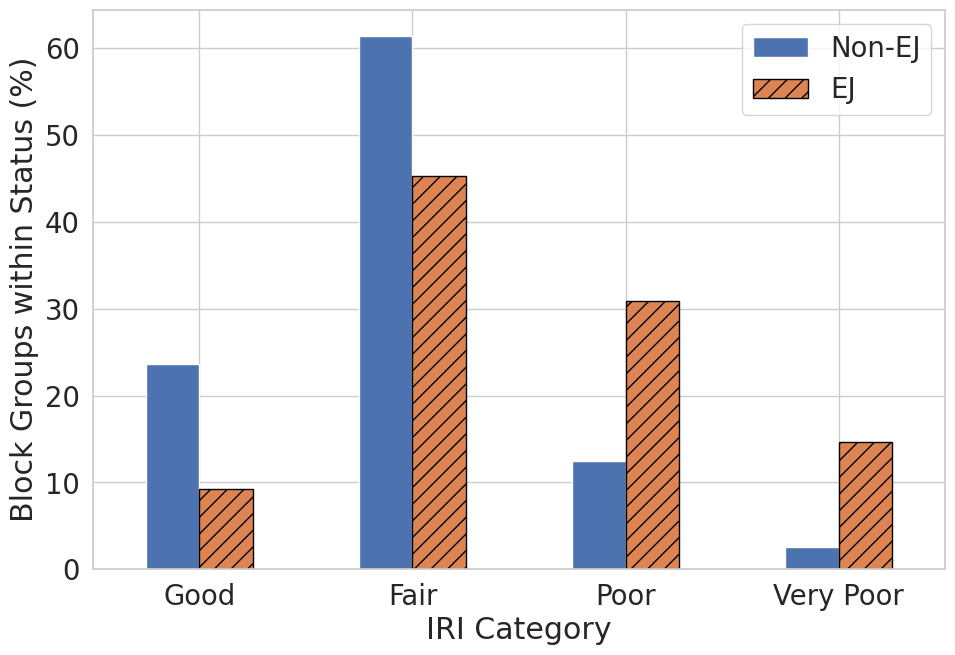

In [38]:
sns.set(font_scale=1.8, style="whitegrid")
bins = [0, 95, 170, 220, Block_Group_Roads['IRI'].max()]
labels = ['Good', 'Fair', 'Poor', 'Very Poor']

# Categorize IRI for the Block_Group_Roads DataFrame
Block_Group_Roads['IRI_Category'] = pd.cut(Block_Group_Roads['IRI'], bins=bins, labels=labels, right=False)

# Group by IRI Category and EJ status, and count the number of rows
iri_ej_counts = Block_Group_Roads.groupby(['IRI_Category', 'EJ'],observed=False).size().unstack().reindex(index=labels)

# Normalize the counts so that EJ and non-EJ each sum to 100%
iri_ej_percentages = iri_ej_counts.apply(lambda x: x / x.sum() * 100, axis=0)

# Plot the grouped bar chart
plt.figure(figsize=(10, 7))
iri_ej_percentages.plot(kind='bar', stacked=False, ax=plt.gca())

ax = plt.gca()

# hatch the EJ bars
for bar in ax.containers[1]:   # usually the 2nd group is EJ
    bar.set_hatch('//')
    bar.set_edgecolor('black')

#plt.title('Distribution of IRI Categories by EJ Status (Percentage within Group)')
plt.xlabel('IRI Category')
plt.ylabel('Block Groups within Status (%)')
plt.xticks(rotation=0)
plt.legend(labels=['Non-EJ', 'EJ']) # Modified legend labels here
plt.tight_layout()
plt.savefig('Dist_by_EJ.png')
plt.show()


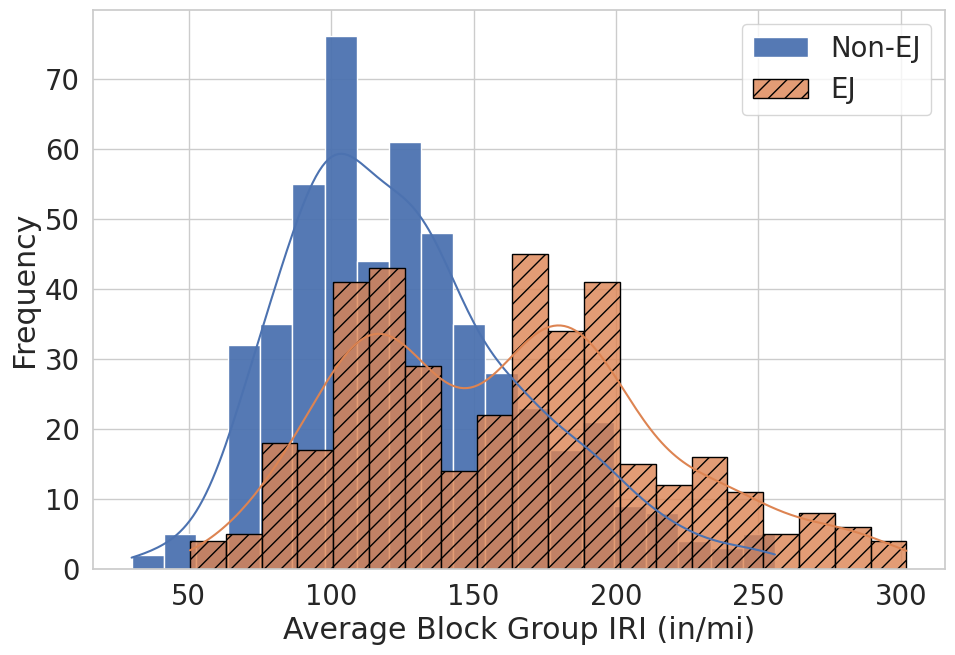

In [40]:
# Separate the DataFrame into EJ and non-EJ groups
ej_block_groups = Block_Group_Roads[Block_Group_Roads['EJ'] == 'Yes']
non_ej_block_groups = Block_Group_Roads[Block_Group_Roads['EJ'] == 'No']

# Plot histograms of IRI for each group
plt.figure(figsize=(10, 7))
sns.histplot(non_ej_block_groups['IRI'], label='Non-EJ', alpha=0.95, kde=True,bins=20)

ax = plt.gca()
n_before = len(ax.patches)

sns.histplot(ej_block_groups['IRI'], label='EJ', alpha=0.8, kde=True, bins=20)

for patch in ax.patches[n_before:]:
    patch.set_hatch('//')
    patch.set_edgecolor('black')

#plt.title('Distribution of IRI in EJ and Non-EJ Block Groups')
plt.xlabel('Average Block Group IRI (in/mi)')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.savefig('IRI_Dist.png')
plt.show()


##Fix and Apply Fix to Block Groups
We can check the improvements for a given budget level

Now that we have roads that are fixed and we have block groups and roads assigned to them, we can do our fixes

the roads are stored in

```
Dist3 - Unfixed
dfs['C']
dfs['C_T']
dfs['C_P']
dfs['C_T_P']
```
The Block Groups are
```
Block_Groups
```
and our
```
objectids_by_geoid_df
```
store the OBJECT ID's of road segments that belong to GEOID which belong to Block Group.

What we need to do, is to create 5 copies of roads

In [ ]:
objectids_by_geoid_df=pd.read_csv('Data/objectids_by_geoid_df.csv')

In [ ]:
Block_Group_BEFORE = calculate_road_metrics_for_block_groups(Dist3, Block_Groups, objectids_by_geoid_df)
Block_Group_C = calculate_road_metrics_for_block_groups(dfs['C'], Block_Groups, objectids_by_geoid_df)
Block_Group_CT = calculate_road_metrics_for_block_groups(dfs['C_T'], Block_Groups, objectids_by_geoid_df)
Block_Group_CP = calculate_road_metrics_for_block_groups(dfs['C_P'], Block_Groups, objectids_by_geoid_df)
Block_Group_CTP = calculate_road_metrics_for_block_groups(dfs['C_T_P'], Block_Groups, objectids_by_geoid_df)

/tmp/ipython-input-2465512415.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  iri_ej_counts_C = Block_Group_C.groupby(['IRI_Category', 'EJ']).size().unstack().reindex(index=labels)
/tmp/ipython-input-2465512415.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  iri_ej_counts_CT = Block_Group_CT.groupby(['IRI_Category', 'EJ']).size().unstack().reindex(index=labels)
/tmp/ipython-input-2465512415.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future defa

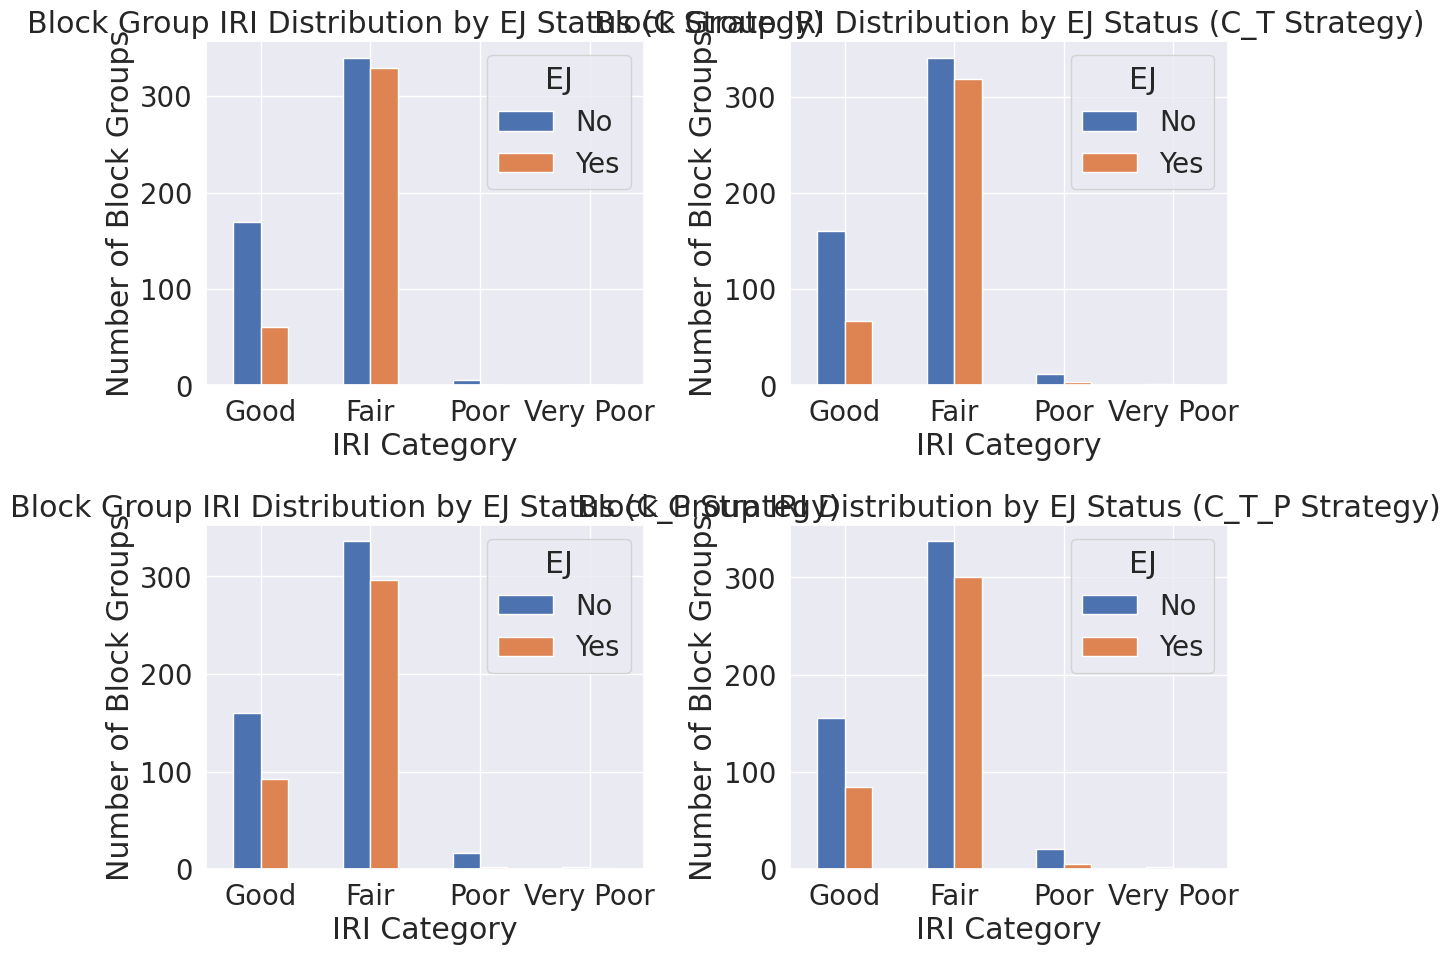

In [ ]:
bins = [0, 95, 170, 220, Block_Group_Roads['IRI'].max()]
labels = ['Good', 'Fair', 'Poor', 'Very Poor']

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Plot for Block_Group_C
Block_Group_C['IRI_Category'] = pd.cut(Block_Group_C['IRI'], bins=bins, labels=labels, right=False)
iri_ej_counts_C = Block_Group_C.groupby(['IRI_Category', 'EJ']).size().unstack().reindex(index=labels)
iri_ej_counts_C.plot(kind='bar', stacked=False, ax=axes[0, 0])
axes[0, 0].set_title('Block Group IRI Distribution by EJ Status (C Strategy)')
axes[0, 0].set_xlabel('IRI Category')
axes[0, 0].set_ylabel('Number of Block Groups')
axes[0, 0].tick_params(axis='x', rotation=0)

# Plot for Block_Group_CT
Block_Group_CT['IRI_Category'] = pd.cut(Block_Group_CT['IRI'], bins=bins, labels=labels, right=False)
iri_ej_counts_CT = Block_Group_CT.groupby(['IRI_Category', 'EJ']).size().unstack().reindex(index=labels)
iri_ej_counts_CT.plot(kind='bar', stacked=False, ax=axes[0, 1])
axes[0, 1].set_title('Block Group IRI Distribution by EJ Status (C_T Strategy)')
axes[0, 1].set_xlabel('IRI Category')
axes[0, 1].set_ylabel('Number of Block Groups')
axes[0, 1].tick_params(axis='x', rotation=0)

# Plot for Block_Group_CP
Block_Group_CP['IRI_Category'] = pd.cut(Block_Group_CP['IRI'], bins=bins, labels=labels, right=False)
iri_ej_counts_CP = Block_Group_CP.groupby(['IRI_Category', 'EJ']).size().unstack().reindex(index=labels)
iri_ej_counts_CP.plot(kind='bar', stacked=False, ax=axes[1, 0])
axes[1, 0].set_title('Block Group IRI Distribution by EJ Status (C_P Strategy)')
axes[1, 0].set_xlabel('IRI Category')
axes[1, 0].set_ylabel('Number of Block Groups')
axes[1, 0].tick_params(axis='x', rotation=0)

# Plot for Block_Group_CTP
Block_Group_CTP['IRI_Category'] = pd.cut(Block_Group_CTP['IRI'], bins=bins, labels=labels, right=False)
iri_ej_counts_CTP = Block_Group_CTP.groupby(['IRI_Category', 'EJ']).size().unstack().reindex(index=labels)
iri_ej_counts_CTP.plot(kind='bar', stacked=False, ax=axes[1, 1])
axes[1, 1].set_title('Block Group IRI Distribution by EJ Status (C_T_P Strategy)')
axes[1, 1].set_xlabel('IRI Category')
axes[1, 1].set_ylabel('Number of Block Groups')
axes[1, 1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

##Equity
Conduct horizontal and vertical equity analysis to make sure the functions are working correctly.

In [ ]:
from scipy.stats import wasserstein_distance

datasets = {
    'Block_Group_BEFORE': Block_Group_BEFORE,
    'Block_Group_C': Block_Group_C,
    'Block_Group_CT': Block_Group_CT,
    'Block_Group_CP': Block_Group_CP,
    'Block_Group_CTP': Block_Group_CTP
}

def gini(x):
    """Calculate the Gini coefficient of a numpy array."""
    total = 0
    for i, xi in enumerate(x[:-1], 1):
        total += np.sum(np.abs(xi - x[i:]))
    return total / (len(x)**2 * np.mean(x))

def weighted_avg_iri(df):
    """Calculate the weighted average IRI."""
    return (df['IRI'] * df['Total_Lane_Miles']).sum() / df['Total_Lane_Miles'].sum()

# Establish the baseline IRI from the 'BEFORE' dataset
baseline_iri = weighted_avg_iri(datasets['Block_Group_BEFORE'])

results = []

for name, df in datasets.items():
    # Gini Coefficient
    gini_coeff = gini(df['IRI'].values)

    # Wasserstein Distance
    ej_yes = df[df['EJ'] == 'Yes']['IRI']
    ej_no = df[df['EJ'] == 'No']['IRI']
    w_dist = wasserstein_distance(ej_yes, ej_no)

    # Weighted Average IRI and Change
    current_iri = weighted_avg_iri(df)
    iri_change = ((current_iri - baseline_iri) / baseline_iri) * 100 if baseline_iri != 0 else 0


    results.append({
        'Dataset': name,
        'Gini': gini_coeff,
        'Wasserstein1D': w_dist,
        'IRI Change (%)': iri_change
    })

results_df = pd.DataFrame(results)
print(results_df)

              Dataset      Gini  Wasserstein1D  IRI Change (%)
0  Block_Group_BEFORE  0.197766      35.519193        0.000000
1       Block_Group_C  0.133437       9.089625      -18.711827
2      Block_Group_CT  0.140182       8.564292      -19.129478
3      Block_Group_CP  0.138322       9.493042      -22.638068
4     Block_Group_CTP  0.142561       8.813990      -22.525161


#Final Implementation with Varying Budget
We can now investigate the impact of lane-mile fixing budget on equity measures.

In [ ]:
maxIRI

600.0

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import wasserstein_distance

def gini(x):
    """Calculate the Gini coefficient of a numpy array."""
    x = np.asarray(x, dtype=np.float64)
    total = 0
    for i, xi in enumerate(x[:-1], 1):
        total += np.sum(np.abs(xi - x[i:]))
    return total / (len(x)**2 * np.mean(x))

def calculate_road_condition(road_df):
    """Calculate the weighted average IRI."""
    return (road_df['IRI'] * road_df['Lane_Mi']).sum() / road_df['Lane_Mi'].sum()


# Main Analysis Function
def analyze_budget_scenarios(Dist3_original, Block_Groups, objectids_by_geoid_df, fix_lengths, IRI_reset=40):
    """
    Runs the full analysis for a list of budget levels.
    """
    all_results = []
    strategies = ['C', 'C_T', 'C_P', 'C_T_P']

    # Gini/Wasserstein are calculated from aggregated Block Groups
    Block_Group_BEFORE = calculate_road_metrics_for_block_groups(Dist3_original, Block_Groups, objectids_by_geoid_df)
    gini_before = gini(Block_Group_BEFORE['IRI'])
    ws_before = wasserstein_distance(
        Block_Group_BEFORE[Block_Group_BEFORE['EJ'] == 'Yes']['IRI'],
        Block_Group_BEFORE[Block_Group_BEFORE['EJ'] == 'No']['IRI']
    )
    # Condition is calculated from the original road network
    condition_before = calculate_road_condition(Dist3_original)

    print("- Baseline Metrics (Before Any Fixes) -")
    print(f"Initial Gini (Block Group): {gini_before:.4f}")
    print(f"Initial Wasserstein (Block Group): {ws_before:.4f}")
    print(f"Initial Condition (Road Network Avg. IRI): {condition_before:.2f}")
    print("-" * 50)

    # Loop over each budget level
    print(f"\nRunning analysis for budget levels: {fix_lengths}")
    for budget in fix_lengths:#first loop through budget
        for strategy_name in strategies: #Then strategy
            print(f"\nRunning analysis for budget: {budget} and strategy {strategy_name}")
            # Create a modified road dataframe for the current scenario
            df_current_strategy = Dist3_original.sort_values(by=strategy_name, ascending=False).copy()

            cumulative_lane_mi = 0
            ids_to_fix = []
            for _, row in df_current_strategy.iterrows():
                if cumulative_lane_mi < budget: #Fix as long as below budget, otherwise break
                    ids_to_fix.append(row['OBJECTID'])
                    cumulative_lane_mi += row['Lane_Mi']
                else:
                    break

            df_current_strategy.loc[df_current_strategy['OBJECTID'].isin(ids_to_fix), 'IRI'] = IRI_reset #set to reset IRI if fixed

            # Gini/Wasserstein require aggregation to block groups
            Block_Group_MODIFIED = calculate_road_metrics_for_block_groups(df_current_strategy, Block_Groups, objectids_by_geoid_df)
            gini_coeff = gini(Block_Group_MODIFIED['IRI'])
            w_dist = wasserstein_distance(
                Block_Group_MODIFIED[Block_Group_MODIFIED['EJ'] == 'Yes']['IRI'],
                Block_Group_MODIFIED[Block_Group_MODIFIED['EJ'] == 'No']['IRI']
            )

            # Condition is the average IRI of the modified road network
            condition = calculate_road_condition(df_current_strategy)

            all_results.append({
                'Lane Miles Fixed': budget,
                'Strategy': strategy_name,
                'Gini': gini_coeff,
                'Wasserstein1D': w_dist,
                'Condition': condition
            })

    print("Analysis complete.")
    return pd.DataFrame(all_results), {'gini': gini_before, 'ws': ws_before, 'condition': condition_before}


# Main
# Define your budget levels
budget_levels = [10, 50, 100, 150, 200, 250, 300]
#budget_levels = [10]
# Run the analysis
results_df, baseline_metrics = analyze_budget_scenarios(Dist3, Block_Groups, objectids_by_geoid_df, budget_levels)

# Display the results in separate tables
if 'results_df' in locals() and not results_df.empty: #Again check to make sure cells were run
    print("\n- Results by Budget Level -")
    for budget in budget_levels:
        print(f"\n- Budget: {budget} Lane Miles -")
        display(results_df[results_df['Lane Miles Fixed'] == budget].drop(columns=['Lane Miles Fixed']).set_index('Strategy')) #All lane miles fixed should be budget anyway
else:
    print("results_df was not properly generated") #Test to make sure I created results_df

- Baseline Metrics (Before Any Fixes) -
Initial Gini (Block Group): 0.1978
Initial Wasserstein (Block Group): 35.5192
Initial Condition (Road Network Avg. IRI): 115.84
--------------------------------------------------

Running analysis for budget levels: [10, 50, 100, 150, 200, 250, 300]

Running analysis for budget: 10 and strategy C

Running analysis for budget: 10 and strategy C_T

Running analysis for budget: 10 and strategy C_P

Running analysis for budget: 10 and strategy C_T_P

Running analysis for budget: 50 and strategy C

Running analysis for budget: 50 and strategy C_T

Running analysis for budget: 50 and strategy C_P

Running analysis for budget: 50 and strategy C_T_P

Running analysis for budget: 100 and strategy C

Running analysis for budget: 100 and strategy C_T

Running analysis for budget: 100 and strategy C_P

Running analysis for budget: 100 and strategy C_T_P

Running analysis for budget: 150 and strategy C

Running analysis for budget: 150 and strategy C_T

Runni

,Gini,Wasserstein1D,Condition
Strategy,,,
C,0.183486,30.092826,114.424914
C_T,0.187421,30.825401,114.594945
C_P,0.183372,29.590426,114.531485
C_T_P,0.185178,29.276075,114.619235



- Budget: 50 Lane Miles -


,Gini,Wasserstein1D,Condition
Strategy,,,
C,0.159152,19.119975,110.181569
C_T,0.163635,19.351535,110.599162
C_P,0.155759,14.378632,110.709991
C_T_P,0.158084,14.219255,110.839180



- Budget: 100 Lane Miles -


...

,Gini,Wasserstein1D,Condition
Strategy,,,
C,0.125464,7.518607,98.490923
C_T,0.133483,7.537156,99.308982
C_P,0.138395,11.759465,100.097904
C_T_P,0.144720,11.263792,100.589881



- Budget: 250 Lane Miles -


,Gini,Wasserstein1D,Condition
Strategy,,,
C,0.121423,6.499832,95.227547
C_T,0.128056,7.481994,96.108809
C_P,0.137699,13.842516,97.067634
C_T_P,0.145306,13.629163,97.591064



- Budget: 300 Lane Miles -


,Gini,Wasserstein1D,Condition
Strategy,,,
C,0.118421,6.084595,92.215389
C_T,0.125470,6.665095,93.133449
C_P,0.139161,15.086818,94.156877
C_T_P,0.147024,16.447926,94.628226


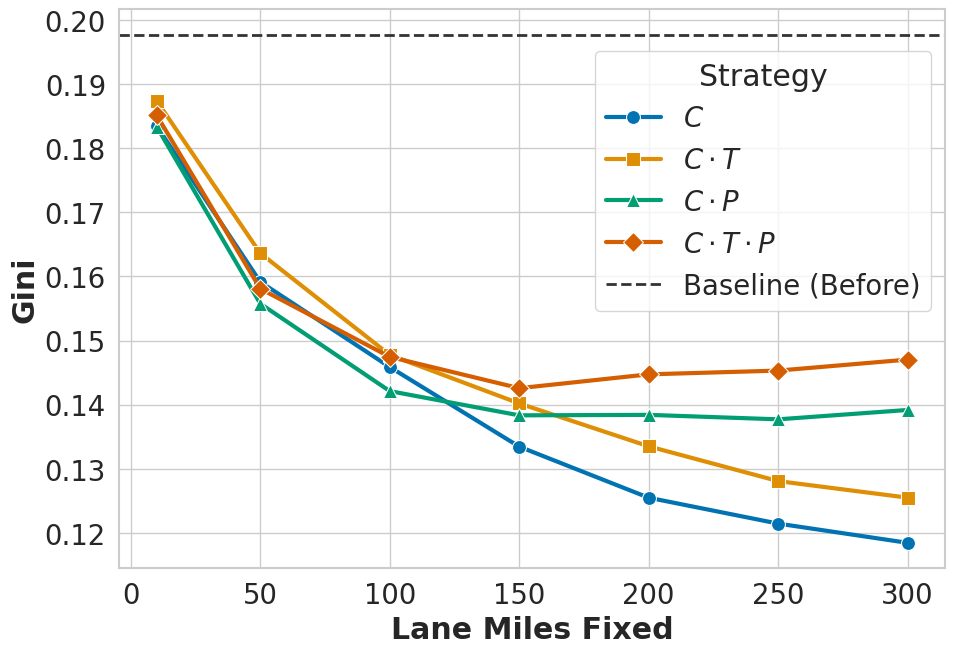

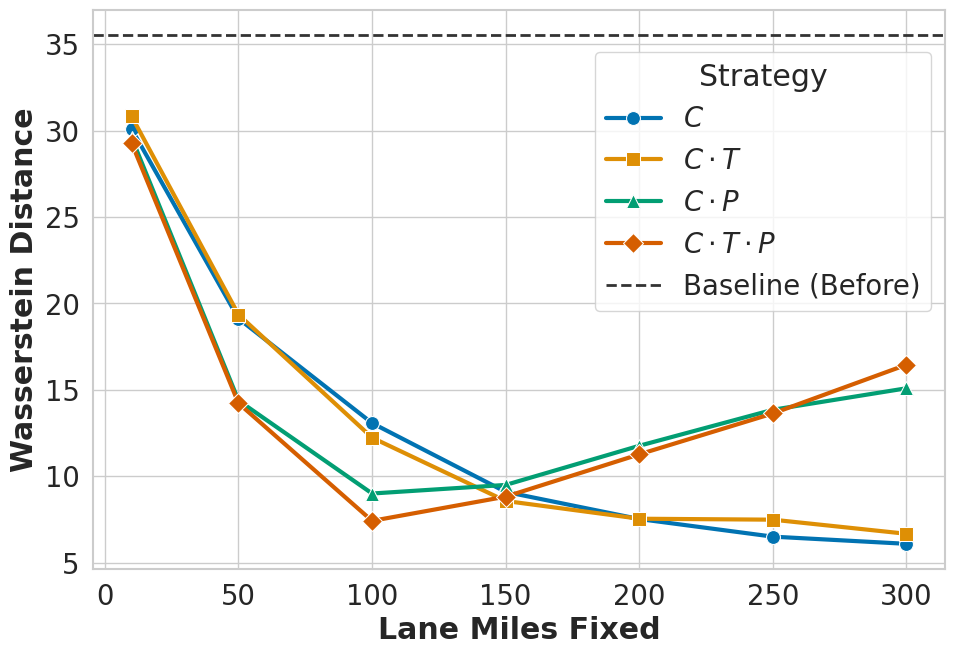

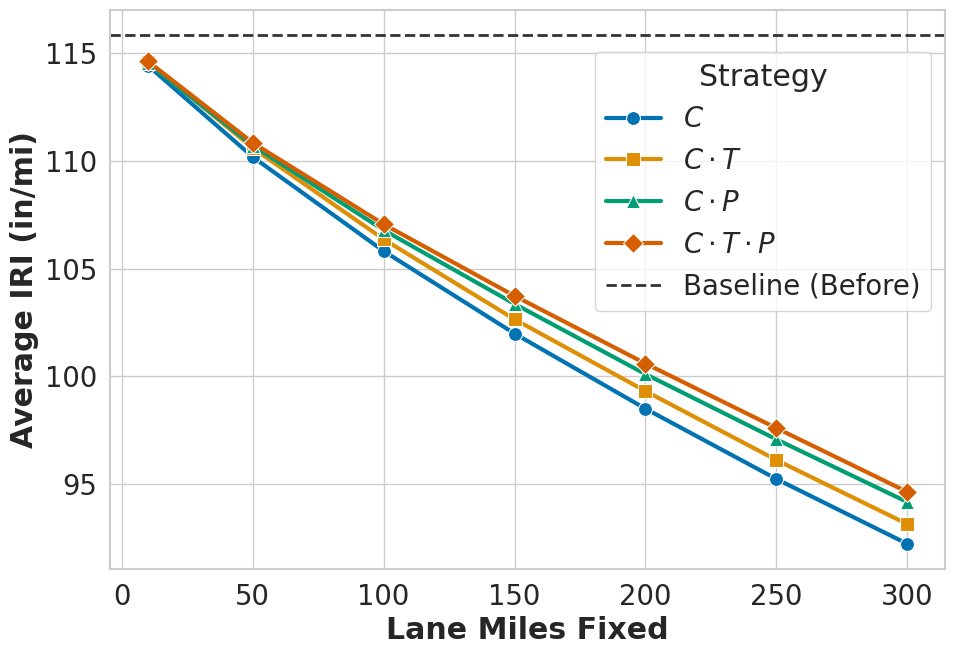

In [ ]:
def plot_results(results_df, baseline_metrics):
    """Plots Gini, Wasserstein, and Condition with LaTeX legends and unique markers."""
    sns.set(font_scale=1.8)
    sns.set_style("whitegrid")
    plt.rcParams.update({
        'font.family': 'sans-serif',
        'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
        'mathtext.fontset': 'custom',  # Force math to use the same sans-serif font
        'mathtext.rm': 'Arial',
        'mathtext.it': 'Arial:italic',
        'mathtext.bf': 'Arial:bold',
        'lines.linewidth': 2.5,        # Thicker lines for visibility
        'axes.linewidth': 1.5,         # Thicker axes
    })
    palette=sns.color_palette("colorblind", n_colors=4)
    # Prepare DataFrame for Plotting
    # Create a copy to avoid modifying the original DataFrame
    plot_df = results_df.copy()

    # 1) Map strategy names to LaTeX strings for the legend
    strategy_map = {
        'C': r'$C$',
        'C_T': r'$C \cdot T$',
        'C_P': r'$C \cdot P$',
        'C_T_P': r'$C \cdot T \cdot P$'
    }
    plot_df['Strategy'] = plot_df['Strategy'].map(strategy_map)

    # Define the order for consistent coloring and markers
    hue_order = [
        r'$C$',
        r'$C \cdot T$',
        r'$C \cdot P$',
        r'$C \cdot T \cdot P$'
    ]

    # 2) Define a list of unique markers for the strategies
    markers_list = ['o', 's', '^', 'D'] # circle, square, triangle_up, diamond

    # Plot Gini Coefficient
    plt.figure(figsize=(10, 7))
    sns.lineplot(data=plot_df,
                 x='Lane Miles Fixed',
                 y='Gini',
                 hue='Strategy',
                 hue_order=hue_order,
                 style='Strategy',    # Use different markers for each strategy
                 markers=markers_list,# Assign the specific markers
                 dashes=False,        # Ensure all lines are solid
                 linewidth=3,markersize=10,
                 palette = palette)
    plt.axhline(y=baseline_metrics['gini'], color='#333333', linewidth=2, linestyle='--', label='Baseline (Before)')
    plt.xlabel('Lane Miles Fixed',fontweight='bold')
    plt.ylabel('Gini',fontweight='bold')
    handles, labels = plt.gca().get_legend_handles_labels()
    plt.legend(handles=handles, labels=labels, title='Strategy', loc='upper right',bbox_to_anchor=(1, 0.95))
    plt.tight_layout()
    plt.show()

    # Plot Wasserstein Distance
    plt.figure(figsize=(10, 7))
    sns.lineplot(data=plot_df,
                 x='Lane Miles Fixed',
                 y='Wasserstein1D',
                 hue='Strategy',
                 hue_order=hue_order,
                 style='Strategy',
                 markers=markers_list,
                 dashes=False,
                 linewidth=3,markersize=10,
                 palette = palette)
    plt.axhline(y=baseline_metrics['ws'], color='#333333', linewidth=2, linestyle='--', label='Baseline (Before)')
    plt.xlabel('Lane Miles Fixed',fontweight='bold')
    plt.ylabel('Wasserstein Distance',fontweight='bold')
    handles, labels = plt.gca().get_legend_handles_labels()
    plt.legend(handles=handles, labels=labels, title='Strategy', loc='upper right',bbox_to_anchor=(1, 0.95))
    plt.tight_layout()
    plt.show()

    #  Plot Condition (Avg. IRI)
    plt.figure(figsize=(10, 7))
    sns.lineplot(data=plot_df,
                 x='Lane Miles Fixed',
                 y='Condition',
                 hue='Strategy',
                 hue_order=hue_order,
                 style='Strategy',
                 markers=markers_list,
                 dashes=False,
                 linewidth=3,markersize=10,
                 palette = palette)
    plt.axhline(y=baseline_metrics['condition'], color='#333333', linewidth=2, linestyle='--', label='Baseline (Before)')
    plt.xlabel('Lane Miles Fixed',fontweight='bold')
    plt.ylabel('Average IRI (in/mi)',fontweight='bold')
    handles, labels = plt.gca().get_legend_handles_labels()
    plt.legend(handles=handles, labels=labels, title='Strategy', loc='upper right',bbox_to_anchor=(1, 0.95))
    plt.tight_layout()
    plt.show()

#Plot the results
if 'results_df' in locals() and not results_df.empty: #Can use the same check.
    plot_results(results_df, baseline_metrics)